# Lab #3 — Game of Thrones Character Network

Elinora Pentcheva


The dataset used in this lab was pulled from Melanie Walsh's Github repo, where she compiles sample datasets for social network analysis: https://github.com/melaniewalsh/sample-social-network-datasets/tree/master/sample-datasets/game-of-thrones

The network is the Game of Thrones character co-occurrence network, originally compiled by A. Beveridge and J. Shan, "Network of Thrones," Math Horizons Magazine , Vol. 23, No. 4 (2016), pp. 18-22.

The data was collected from the first five novels of George R.R. Martin's *A Song of Ice and Fire* series, recording every instance where two named characters appeared within 15 words of each other in the text. Each such co-occurrence counted as an interaction, and the total number of co-occurrences between any two characters became the edge weight. The resulting network captures the narrative proximity of characters across the books — characters who share scenes, dialogue, or are frequently mentioned together.


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from networkx.algorithms.community import girvan_newman

# Load data
nodes_df = pd.read_csv('got-nodes.csv')
edges_df = pd.read_csv('got-edges.csv')

print('Nodes DataFrame:')
print(nodes_df.head())
print('\nEdges DataFrame:')
print(edges_df.head())

Nodes DataFrame:
        Id    Label
0    Aemon    Aemon
1    Grenn    Grenn
2  Samwell  Samwell
3    Aerys    Aerys
4    Jaime    Jaime

Edges DataFrame:
  Source   Target  Weight
0  Aemon    Grenn       5
1  Aemon  Samwell      31
2  Aerys    Jaime      18
3  Aerys   Robert       6
4  Aerys   Tyrion       5


In [3]:
# Build the graph
G = nx.from_pandas_edgelist(edges_df, 'Source', 'Target', edge_attr='Weight')

print('Graph built successfully.')
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Graph built successfully.
Nodes: 107
Edges: 352


## #1. Network Description and Basic Topology


In [5]:
# --- Basic topology ---
print('=== NETWORK DESCRIPTION ===')
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')
print(f'Directed: No (co-occurrence is a symmetric relationship)')
print(f'Weighted: Yes (weight = number of co-occurrences within 15 words)')
print(f'Density: {nx.density(G):.4f}')
print(f'Is fully connected (one component): {nx.is_connected(G)}')
print(f'Average degree: {sum(d for n,d in G.degree()) / G.number_of_nodes():.2f}')
print(f'Average clustering coefficient: {nx.average_clustering(G):.4f}')
print(f'Average shortest path length: {nx.average_shortest_path_length(G):.4f}')

print('\n--- Edge Weight Distribution ---')
w = edges_df['Weight']
print(f'Min weight: {w.min()}')
print(f'Max weight: {w.max()}')
print(f'Mean weight: {w.mean():.1f}')
print(f'Median weight: {w.median()}')

print('\n--- Top 10 Characters by Degree (number of co-characters) ---')
top_degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
for name, deg in top_degree:
    print(f'  {name}: {deg}')

=== NETWORK DESCRIPTION ===
Number of nodes: 107
Number of edges: 352
Directed: No (co-occurrence is a symmetric relationship)
Weighted: Yes (weight = number of co-occurrences within 15 words)
Density: 0.0621
Is fully connected (one component): True
Average degree: 6.58
Average clustering coefficient: 0.5514
Average shortest path length: 2.9039

--- Edge Weight Distribution ---
Min weight: 4
Max weight: 96
Mean weight: 12.3
Median weight: 7.0

--- Top 10 Characters by Degree (number of co-characters) ---
  Tyrion: 36
  Jon: 26
  Sansa: 26
  Robb: 25
  Jaime: 24
  Tywin: 22
  Cersei: 20
  Arya: 19
  Robert: 18
  Joffrey: 18


### Description

The network has 107 nodes (named characters) and 352 edges (co-occurrence relationships). The ties are undirected — there is no distinction between "source" and "target," as we are interested in co-occurrence only. The ties are also weighted, with weights ranging from 4 to 96 and a mean of about 12.3. A weight of 4 means two characters barely cross paths in the narrative; a weight of 96 (Tyrion and Cersei) means they are the most narratively intertwined pair in the entire series.

The network is fully connected — every character can reach every other character through some chain of co-occurrences, with an average shortest path of just 2.9 steps, reflecting the deeply intertwined narrative devices and plotlines of the book.

The density is 0.062, meaning only about 6% of all possible character pairings actually interact in the text. This is low but expected — with 107 characters across sprawling storylines and different continents, most pairs never exist in the same geographic setting, let alone share a scene. The average clustering coefficient of 0.55 is quite high, indicating that when two characters both know a third character, they tend to know each other too — which makes narrative sense (people in the same castle or storyline cluster together).

The most connected character is Tyrion Lannister with a degree of 36, interacting with 36 unique other characters. Jon Snow and Sansa Stark are next (26 each). This network has no node attribute data beyond character names, but being a gigantic nerd I will base my interpretation on knowledge of the characters' storylines and affiliations.


## #2. Girvan-Newman Community Detection
Note: didn't run the walktrap for this since not in lab instructions, even though it was in the provided code*


In [6]:
# Run Girvan-Newman and evaluate modularity at each k
print('Running Girvan-Newman community detection')

gen = girvan_newman(G)
modularities = {}
partitions = {}

for k in range(2, 16):
    partition = next(gen)
    mod = nx.community.modularity(G, partition)
    modularities[k] = mod
    partitions[k] = partition
    print(f'  k={k:2d} communities  |  modularity = {mod:.4f}')

best_k = max(modularities, key=modularities.get)
best_mod = modularities[best_k]
best_partition = partitions[best_k]

print(f'\n>>> Best partition: k={best_k} communities (modularity = {best_mod:.4f})')

Running Girvan-Newman community detection
  k= 2 communities  |  modularity = 0.1342
  k= 3 communities  |  modularity = 0.1491
  k= 4 communities  |  modularity = 0.3554
  k= 5 communities  |  modularity = 0.3546
  k= 6 communities  |  modularity = 0.3539
  k= 7 communities  |  modularity = 0.3697
  k= 8 communities  |  modularity = 0.3689
  k= 9 communities  |  modularity = 0.3680
  k=10 communities  |  modularity = 0.3671
  k=11 communities  |  modularity = 0.3662
  k=12 communities  |  modularity = 0.3645
  k=13 communities  |  modularity = 0.3627
  k=14 communities  |  modularity = 0.3609
  k=15 communities  |  modularity = 0.3591

>>> Best partition: k=7 communities (modularity = 0.3697)


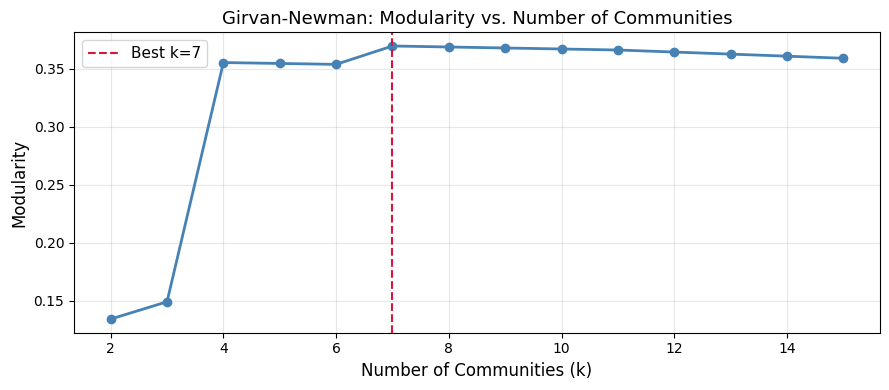

In [7]:
# Plot modularity vs k
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(modularities.keys()), list(modularities.values()), 'o-', color='steelblue', linewidth=2)
ax.axvline(best_k, color='crimson', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('Number of Communities (k)', fontsize=12)
ax.set_ylabel('Modularity', fontsize=12)
ax.set_title('Girvan-Newman: Modularity vs. Number of Communities', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Show community membership
sorted_comms = sorted(best_partition, key=len, reverse=True)

print(f'=== {best_k} Communities Found by Girvan-Newman ===')
for i, comm in enumerate(sorted_comms):
    print(f'\nCommunity {i+1} ({len(comm)} members):')
    print('  ', ', '.join(sorted(comm)))

=== 7 Communities Found by Girvan-Newman ===

Community 1 (60 members):
   Aerys, Amory, Anguy, Arya, Balon, Beric, Brienne, Bronn, Brynden, Catelyn, Cersei, Chataya, Doran, Eddard, Edmure, Elia, Ellaria, Gendry, Gregor, Hoster, Ilyn, Jaime, Jeyne, Joffrey, Jon Arryn, Kevan, Lancel, Loras, Lothar, Lysa, Mace, Margaery, Marillion, Meryn, Myrcella, Oberyn, Olenna, Petyr, Podrick, Pycelle, Ramsay, Renly, Rickard, Rickon, Robb, Robert, Robert Arryn, Roose, Roslin, Sandor, Sansa, Shae, Stannis, Theon, Thoros, Tommen, Tyrion, Tywin, Varys, Walder

Community 2 (23 members):
   Aemon, Alliser, Bowen, Craster, Dalla, Eddison, Gilly, Grenn, Hodor, Janos, Jojen, Jon, Karl, Mance, Meera, Melisandre, Orell, Qhorin, Rattleshirt, Samwell, Styr, Val, Ygritte

Community 3 (15 members):
   Aegon, Barristan, Belwas, Daario, Daenerys, Drogo, Illyrio, Irri, Jorah, Kraznys, Missandei, Rakharo, Rhaegar, Viserys, Worm

Community 4 (4 members):
   Cressen, Davos, Salladhor, Shireen

Community 5 (3 members):
  

*see interpretation below*


## #3. How Many Groups Does the Algorithm Find?


In [9]:
print(f'Girvan-Newman found {best_k} communities (at peak modularity = {best_mod:.4f})')
print()
print('Community sizes:')
for i, comm in enumerate(sorted_comms):
    print(f'  Community {i+1}: {len(comm)} members')

Girvan-Newman found 7 communities (at peak modularity = 0.3697)

Community sizes:
  Community 1: 60 members
  Community 2: 23 members
  Community 3: 15 members
  Community 4: 4 members
  Community 5: 3 members
  Community 6: 1 members
  Community 7: 1 members


### Results

Girvan-Newman finds 7 communities at its optimal (peak-modularity) cut. The partition is very unequal in size, reflecting the differential density of the distinct storylines:

| Community | Size | Narrative Identity |
|-----------|------|--------------------|
| 1 | 60 | Westeros / King's Landing / Main Court |
| 2 | 23 | The Wall, Night's Watch, Wildlings |
| 3 | 15 | Daenerys' storyline (Essos) |
| 4 | 4  | Dragonstone / Stannis' inner circle |
| 5 | 3  | Bran's storyline (Winterfell, North) |
| 6 | 1  | Qyburn (isolated) |
| 7 | 1  | Walton (isolated) |

Community 1 is very large — 60 of 107 nodes — because so much of the action in the books centers on King's Landing and the political machinations of Westeros. The other communities map quite neatly onto the major geographic and narrative arcs of the series. The two singleton communities (Qyburn and Walton) are characters with very few connections to the main network, left as isolated nodes when the bridge edges connecting them to larger clusters were removed. Qyburn is a former maester who becomes Cersei's advisor, and she is the character he interacts with almost exclusively. The scenes featuring him are often him reporting directly to her, carrying out her orders, or spying/torturing other unnamed characters, so it makes sense that we do not see him with other main characters very often. Walton is a man-at-arms of house Bolton who also interacts with very few people throughout the story, serving the story mainly when he escorts Jaime Lannister to King's Landing.


## #4. Network Visualization: Nodes Colored by Girvan-Newman Community


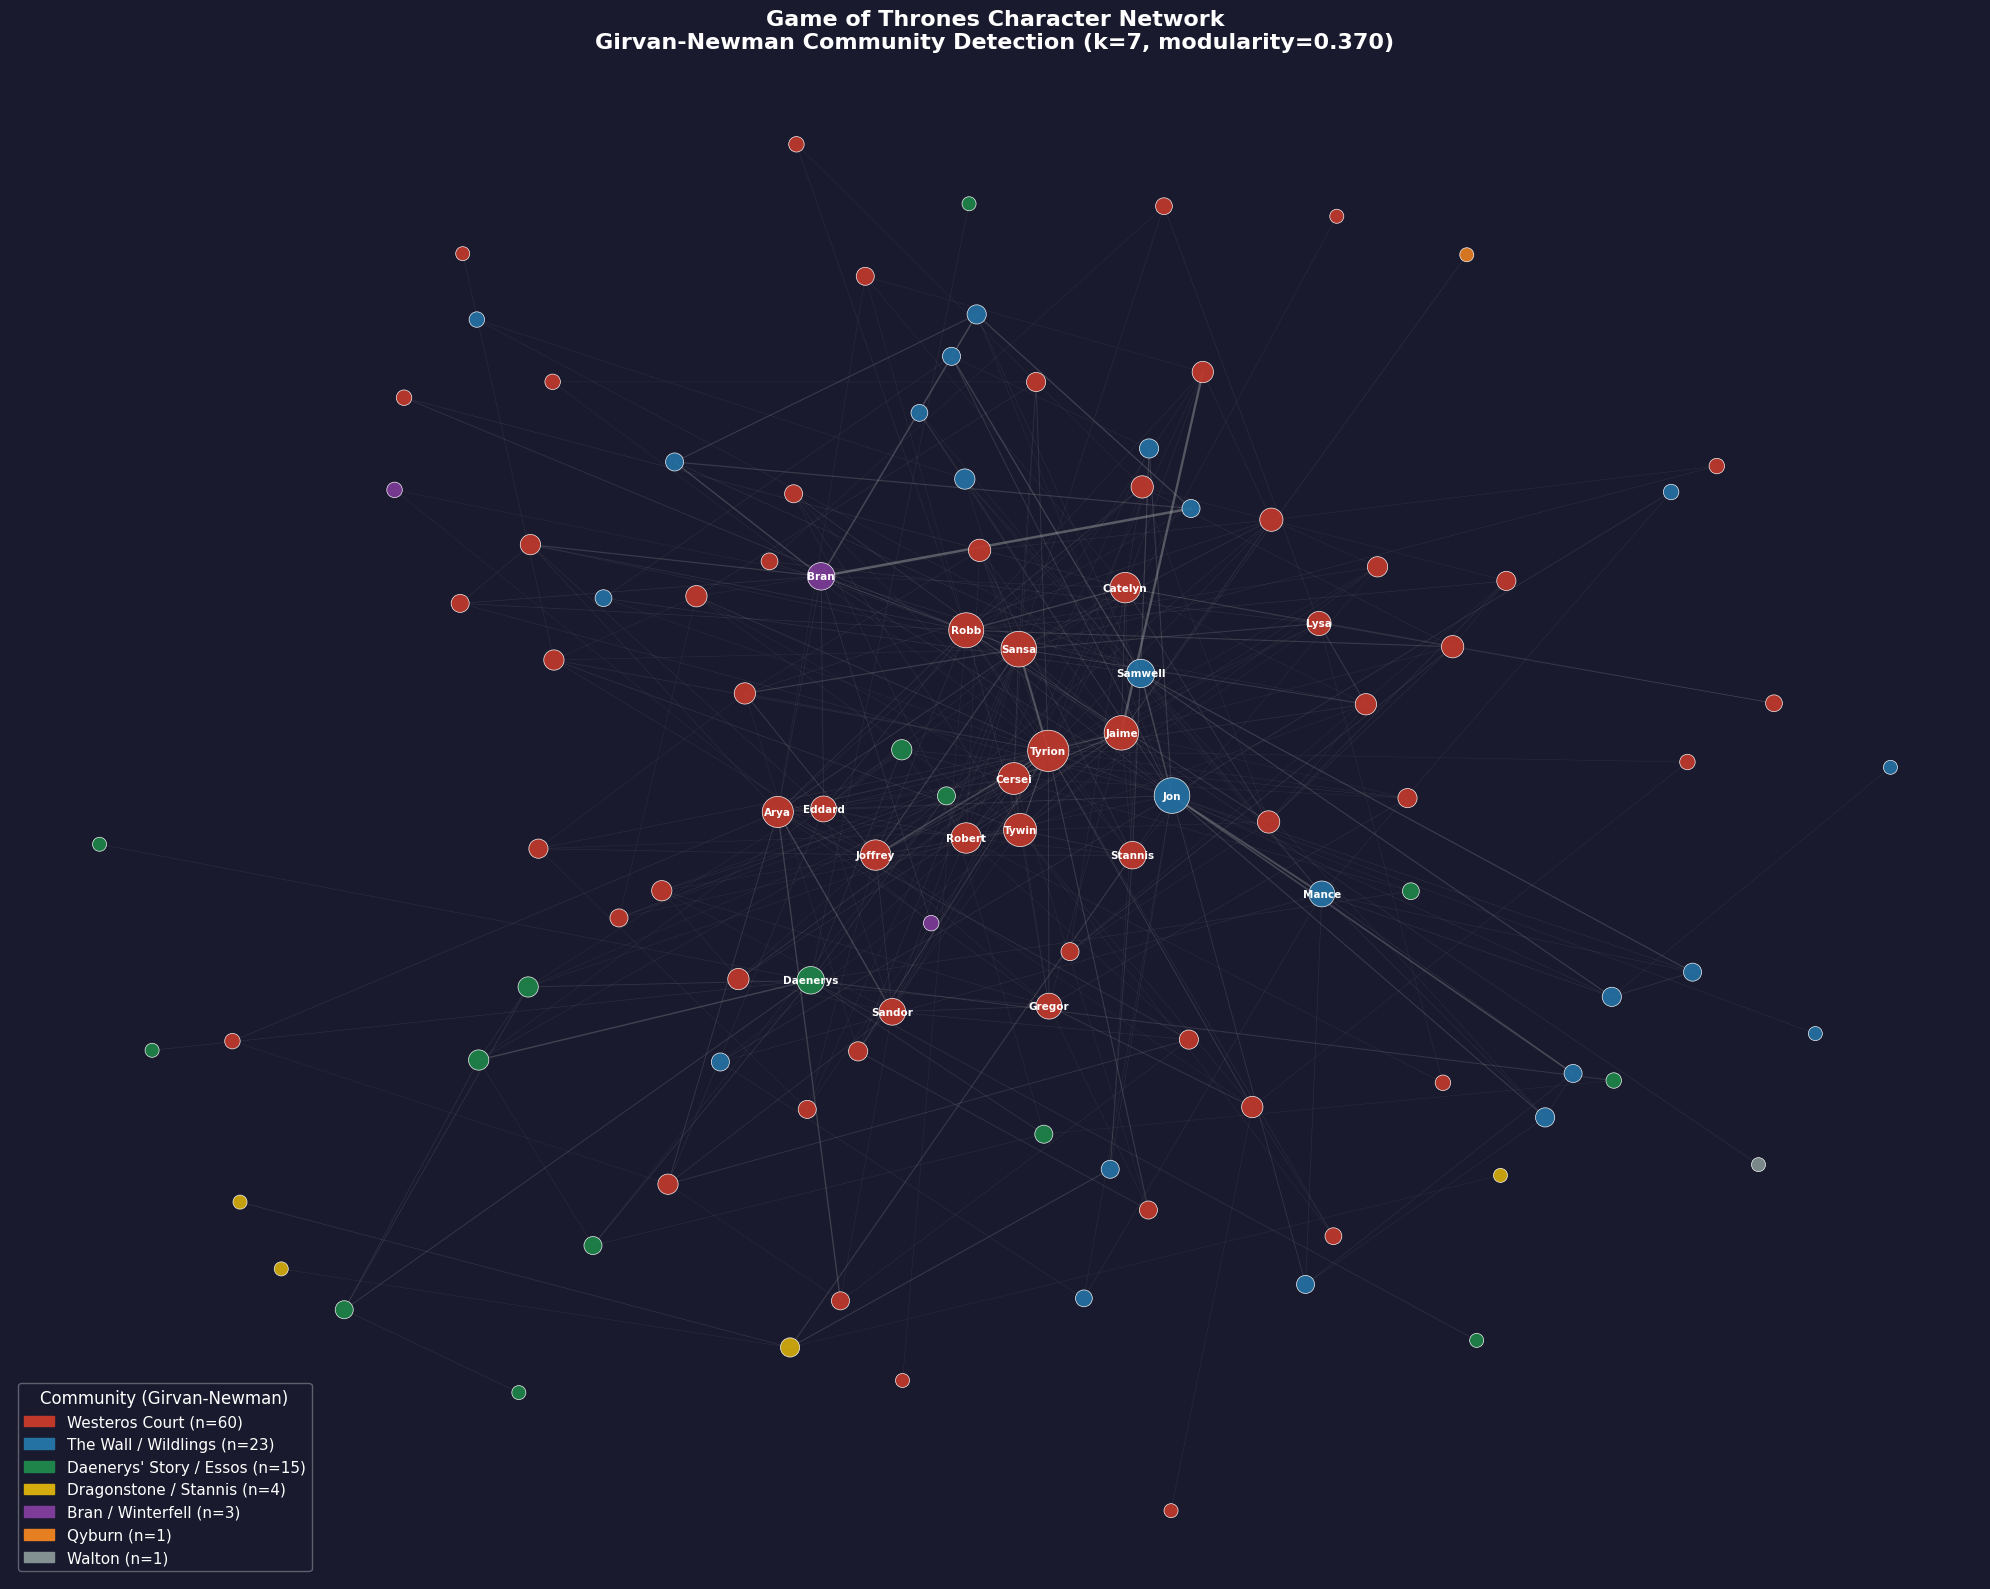

In [10]:
# Assign community label per node (sorted by size, largest = 0)
node_comm_label = {}
for i, comm in enumerate(sorted_comms):
    for node in comm:
        node_comm_label[node] = i

# Color palette
colors = ['#C0392B', '#2471A3', '#1E8449', '#D4AC0D', '#7D3C98', '#E67E22', '#839192']
comm_labels = [
    'Westeros Court (n=60)',
    'The Wall / Wildlings (n=23)',
    "Daenerys' Story / Essos (n=15)",
    'Dragonstone / Stannis (n=4)',
    'Bran / Winterfell (n=3)',
    'Qyburn (n=1)',
    'Walton (n=1)'
]

node_colors = [colors[node_comm_label[n]] for n in G.nodes()]

# Node sizes proportional to degree
degrees = dict(G.degree())
max_deg = max(degrees.values())
node_sizes = [80 + (degrees[n] / max_deg) * 800 for n in G.nodes()]

# Spring layout
pos = nx.spring_layout(G, seed=42, k=1.2, iterations=100)

fig, ax = plt.subplots(figsize=(20, 16))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Draw edges
edge_weights = [G[u][v]['Weight'] for u, v in G.edges()]
max_w = max(edge_weights)
for (u, v), w in zip(G.edges(), edge_weights):
    alpha = 0.1 + 0.35 * (w / max_w)
    width = 0.3 + 1.5 * (w / max_w)
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color='#aaaaaa', alpha=alpha, linewidth=width, zorder=1)

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.92,
                       linewidths=0.5, edgecolors='white')

# Label high-degree nodes only
labels_to_show = {n: n for n, d in G.degree() if d >= 10}
nx.draw_networkx_labels(G, pos, labels=labels_to_show, ax=ax,
                        font_size=7.5, font_color='white', font_weight='bold')

# Legend
patches = [mpatches.Patch(color=colors[i], label=comm_labels[i]) for i in range(7)]
legend = ax.legend(handles=patches, loc='lower left', fontsize=11,
                   framealpha=0.3, facecolor='#1a1a2e', edgecolor='white',
                   labelcolor='white', title='Community (Girvan-Newman)',
                   title_fontsize=12)
legend.get_title().set_color('white')

ax.set_title(
    'Game of Thrones Character Network\n'
    'Girvan-Newman Community Detection (k=7, modularity=0.370)',
    fontsize=16, color='white', pad=20, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.show()

### Notes on the graph

Nodes are sized by degree, and node labels are shown only for characters with 10 or more connections, to avoid clutter. Edge opacity and thickness both scale with interaction weight, so thicker/brighter lines represent more frequent co-occurrences in the text.

The red cluster (Westeros Court) dominates the center of the graph, reflecting how much of the narrative action flows through King's Landing. The blue cluster (The Wall) sits to one side, connected to the main cluster primarily through Jon Snow. The green cluster (Daenerys) is even more peripheral — geographically, Essos is far from Westeros, and that separation is faithfully reflected in the network structure.


## #5. Does the Partitioning Make Sense?


In [11]:
# Summarize each community with its key characters
print('=== Community Roster and Interpretation ===')
interpretations = [
    'Westeros political storyline: King\'s Landing, Lannister/Stark/Baratheon conflict',
    'The Wall, Night\'s Watch, Wildlings (Jon Snow\'s arc)',
    'Daenerys Targaryen storyline in Essos',
    'Dragonstone — Stannis Baratheon\'s inner circle',
    'Bran Stark storyline (Winterfell, going North)',
    'Qyburn — peripheral character, isolated node',
    'Walton — peripheral character, isolated node'
]
for i, (comm, interp) in enumerate(zip(sorted_comms, interpretations)):
    print(f'\nCommunity {i+1} ({len(comm)} nodes):')
    print(f'  Interpretation: {interp}')
    top = sorted(comm, key=lambda n: degrees.get(n, 0), reverse=True)[:5]
    print(f'  Top characters by degree: {", ".join(top)}')

=== Community Roster and Interpretation ===

Community 1 (60 nodes):
  Interpretation: Westeros political storyline: King's Landing, Lannister/Stark/Baratheon conflict
  Top characters by degree: Tyrion, Sansa, Robb, Jaime, Tywin

Community 2 (23 nodes):
  Interpretation: The Wall, Night's Watch, Wildlings (Jon Snow's arc)
  Top characters by degree: Jon, Samwell, Mance, Janos, Qhorin

Community 3 (15 nodes):
  Interpretation: Daenerys Targaryen storyline in Essos
  Top characters by degree: Daenerys, Barristan, Jorah, Rhaegar, Belwas

Community 4 (4 nodes):
  Interpretation: Dragonstone — Stannis Baratheon's inner circle
  Top characters by degree: Davos, Shireen, Salladhor, Cressen

Community 5 (3 nodes):
  Interpretation: Bran Stark storyline (Winterfell, going North)
  Top characters by degree: Bran, Luwin, Nan

Community 6 (1 nodes):
  Interpretation: Qyburn — peripheral character, isolated node
  Top characters by degree: Qyburn

Community 7 (1 nodes):
  Interpretation: Walton — 

### Analysis

The Girvan-Newman partition makes excellent narrative sense. Each community corresponds almost perfectly to one of the major geographic and storyline arcs of the series:

Community 1 — Westeros Court (n=60): This is the political heart of the series — the Lannisters, Starks, Baratheons, and everyone in King's Landing. Tyrion, Cersei, Sansa, Robb, Ned, Joffrey, Jaime, and Tywin all cluster together here. The community is large because so many characters orbit the Iron Throne, and their narrative fates are constantly intertwined as they collaborate/clash/collude. The algorithm correctly identifies this as a single dense community, even though within it there are factions with different loyalties (Lannisters vs. Starks) - they nevertheless co-occur consistently.

Community 2 — The Wall / Wildlings (n=23): Jon Snow's entire storyline is cleanly separated here — Samwell, Aemon, Ygritte, Mance Rayder, the Night's Watch officers, and the Wildling leaders. This group is geographically and narratively isolated from the southern action, as they are focused on their own fight against the Night King beyond the Wall, while the first group are concerned with the iron throne.

Community 3 — Daenerys' Story / Essos (n=15): Daenerys, Drogo, Jorah, Viserys, Missandei, Barristan, Daario, and the other characters of her storyline form a tight cluster entirely separate from Westeros. Because Daenerys spends the entirety of the five published books across the Narrow Sea, her characters almost never co-occur with Westerosi characters. If and when George R.R. Martin decides to publish the next two tomes (he won't, but I can still pretend) we could rerun this analysis and see how she mingles with the first two groups.

Community 4 — Dragonstone / Stannis (n=4): Davos, Cressen, Shireen, and Salladhor Saan form Stannis Baratheon's intimate inner circle. This small community reflects how isolated Dragonstone is narratively — Stannis's plotline involves relatively few characters who are tightly bound to each other and weakly connected to the larger Westeros cluster.

Community 5 — Bran / Winterfell (n=3): Bran, Luwin, and Old Nan form a tiny cluster. Bran's storyline is distinctive in that it involves a very small cast of characters (especially after Winterfell is sacked) and his journey beyond the Wall is nearly entirely separate from the main action. Three nodes is small, but it reflects the reality that Bran's POV chapters involve very few recurring co-characters as he makes his way away from everyone and everything else to pursue his own destiny.

Communities 6 & 7 — Singletons: Qyburn and Walton each end up isolated. Both are peripheral characters with very few connections, as described in my notes on #3. When their weak bridge edges are removed during the betweenness-cutting process, they are left as singletons.

Overall, the Girvan-Newman partition is remarkably interpretable. Without any metadata — no house labels, no geographic tags, no explicit faction information — the algorithm recovers the major story arcs of the series purely from co-occurrence patterns in the text, and identifies groups that any reader or series fan would immediately recognize. The three largest communities (Westeros, The Wall, Essos) map precisely onto the three primary geographic settings and plotlines. The two smaller communities (Stannis, Bran) correspond to the most isolated sub-arcs of the story. The only weakness is the two singleton communities, which are an artifact of the algorithm's aggressive edge-removal rather than genuine isolated subgroups.